# Scanner Validation
Comparison of scanners against human defined labels. 

This notebook uses config files in analysis/configs for reproducibility.
Results are saved out in corresponding results directories, defined in the config files.

Analysis driven by self-describing `scan_id=*` directories under
`evals/scans/{TARGET_SCANNER}/{SPLIT}/`. Every plot can be examined per
`scan_id` (a single scanner run) or pooled across all scan_ids covering the
same target scanner.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/jeffm/projects/scanner_evaluation")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from analysis.scan_utils import (
    load_scan_results,
    load_validations,
    add_violation_flags,
    summarize_grade_distribution,
    summarize_violation_rates,
    build_comparison_table,
)
from analysis.analysis_utils import (
    BENCHMARK_ALIASES,
    MODEL_NAME_ALIASES,
    GRADE_LEVELS,
    SCORE_COLORS,
    shorten_model,
    violation_rate,
    confusion_matrix,
    quadratic_weighted_kappa,
    threshold_metrics,
    draw_cm,
    make_savers,
)

pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", 20)

Run-specific values (target scanner, split, threshold, scan_id filters, results
subdirectory) are loaded from a YAML file under `analysis/configs/`. Point
`CONFIG_PATH` at a different file to switch runs. Display invariants (model
and benchmark aliases, grade colors) are kept inline below.


In [2]:
import yaml

# Per-run config. Swap this path to analyze a different scan / split.
CONFIG_PATH = PROJECT_ROOT / "analysis" / "configs" / "guessing_test_gpt_vs_claude.yaml"

with open(CONFIG_PATH) as f:
    _cfg = yaml.safe_load(f)

TARGET_SCANNER: str = _cfg["target_scanner"]

display(Markdown(f"# Scanner Validation: {TARGET_SCANNER}"))
display(Markdown(f"## {TARGET_SCANNER} — Configuration"))
SPLIT: str = _cfg["split"]
SCANNER_KEY: str | None = _cfg.get("scanner_key")
VIOLATION_THRESHOLD: int = _cfg["violation_threshold"]
INCLUDE_SCAN_IDS: list[str] = list(_cfg.get("include_scan_ids") or [])
EXCLUDE_SCAN_IDS: list[str] = list(_cfg.get("exclude_scan_ids") or [])

# validation_file: null → use all CSVs in VALIDATION_DIR; string → one file;
# list → subset of files. Names match either the filename or its stem.
_vf = _cfg.get("validation_file")
VALIDATION_FILES: list[str] | None = (
    None if _vf is None
    else ([_vf] if isinstance(_vf, str) else list(_vf))
)

SCAN_RESULTS_DIR = PROJECT_ROOT / "evals" / "scans" / TARGET_SCANNER / SPLIT / "scan-results"
VALIDATION_DIR = PROJECT_ROOT / "evals" / "scans" / TARGET_SCANNER / SPLIT / "validation"

_results_subdir = _cfg.get("results_subdir")
RESULTS_DIR: Path | None = (
    PROJECT_ROOT / "analysis" / "results" / TARGET_SCANNER / SPLIT / _results_subdir
    if _results_subdir
    else None
)
if RESULTS_DIR is not None:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

save_fig, save_table = make_savers(RESULTS_DIR)

print(f"CONFIG           = {CONFIG_PATH.relative_to(PROJECT_ROOT)}")
print(f"TARGET_SCANNER   = {TARGET_SCANNER}")
print(f"SPLIT            = {SPLIT}")
print(f"THRESHOLD        = {VIOLATION_THRESHOLD}")
print(f"SCAN_RESULTS     = {SCAN_RESULTS_DIR}")
print(f"VALIDATION       = {VALIDATION_DIR}")
print(f"VALIDATION_FILES = {VALIDATION_FILES if VALIDATION_FILES else '(all CSVs in VALIDATION_DIR)'}")
print(f"RESULTS_DIR      = {RESULTS_DIR if RESULTS_DIR else '(not saving outputs)'}")


# Scanner Validation: guessing

## guessing — Configuration

CONFIG           = analysis/configs/guessing_test_gpt_vs_claude.yaml
TARGET_SCANNER   = guessing
SPLIT            = test
THRESHOLD        = 2
SCAN_RESULTS     = /home/jeffm/projects/scanner_evaluation/evals/scans/guessing/test/scan-results
VALIDATION       = /home/jeffm/projects/scanner_evaluation/evals/scans/guessing/test/validation
VALIDATION_FILES = (all CSVs in VALIDATION_DIR)
RESULTS_DIR      = /home/jeffm/projects/scanner_evaluation/analysis/results/guessing/test/gpt_vs_claude_comp


`load_scan_results` discovers every `scan_id=*` directory, reads each parquet,
and attaches scanner metadata from `_scan.json`. We then derive a few display
columns purely from columns already present in the parquet/_scan.json — no
provenance CSV required.

In [3]:
raw_scans = load_scan_results(SCAN_RESULTS_DIR)
print(f"Loaded {len(raw_scans):,} rows from {raw_scans['scanner_source'].nunique()} scan_id(s).")
present_keys = sorted(raw_scans["scanner_key"].dropna().unique())
print(f"Scanner keys present: {present_keys}")

# Resolve scanner_key (auto-detect if not set; warn on directory/key mismatch).
if SCANNER_KEY is not None:
    resolved_scanner_key = SCANNER_KEY
elif len(present_keys) == 1:
    resolved_scanner_key = present_keys[0]
    if resolved_scanner_key != TARGET_SCANNER:
        print(f"⚠ Directory name '{TARGET_SCANNER}' differs from parquet scanner_key "
              f"'{resolved_scanner_key}'. Using '{resolved_scanner_key}'.")
else:
    raise RuntimeError(
        f"Multiple scanner_keys present ({present_keys}). Set SCANNER_KEY explicitly."
    )

display(Markdown(f"## {resolved_scanner_key} — Load scan results"))

scans = raw_scans.copy()
scans["scan_id"] = scans["scanner_source"].str.removeprefix("scan_id=")
scans["eval_file"] = scans["transcript_source_uri"].fillna("").map(lambda p: Path(p).name if p else None)
scans["scanner_model"] = scans["scanner_model"].map(shorten_model)
scans["eval_generation_model"] = scans["transcript_model"].map(shorten_model)
scans["benchmark"] = scans["transcript_task_set"].map(lambda b: BENCHMARK_ALIASES.get(b, b))
scans["scanner_label"] = scans["scanner_model"].fillna("(no model)").astype(str) + " · " + scans["scan_id"].str[:6]

scans = scans[scans["scanner_key"] == resolved_scanner_key].copy()
if INCLUDE_SCAN_IDS:
    scans = scans[scans["scan_id"].isin(INCLUDE_SCAN_IDS)].copy()
if EXCLUDE_SCAN_IDS:
    scans = scans[~scans["scan_id"].isin(EXCLUDE_SCAN_IDS)].copy()

scan_id_order = (
    scans.sort_values("scan_timestamp")
    .drop_duplicates("scan_id")["scan_id"]
    .tolist()
)
scanner_label_by_scan_id = (
    scans.drop_duplicates("scan_id").set_index("scan_id")["scanner_label"].to_dict()
)

print(f"After filtering: {len(scans):,} rows · {len(scan_id_order)} scan_id(s)")
print()
display(
    scans.drop_duplicates("scan_id")[
        ["scan_id", "scanner_label", "scanner_model", "scan_timestamp"]
    ].sort_values("scan_timestamp").reset_index(drop=True)
)


Loaded 1,152 rows from 1 scan_id(s).
Scanner keys present: ['guessing']


## guessing — Load scan results

After filtering: 1,152 rows · 1 scan_id(s)



,scan_id,scanner_label,scanner_model,scan_timestamp
0,Vnb6GhThvWxeBFz427kMRb,gpt-5.4 · Vnb6Gh,gpt-5.4,2026-05-05T20:23:54.325641+10:00


If `validation/` is missing or empty we set `validation = None` and the
ground-truth-comparison sections later in the notebook print a skip notice.

In [4]:
display(Markdown(f"## {resolved_scanner_key} — Load validation grades"))
validation: pd.DataFrame | None = None

if VALIDATION_DIR.exists() and any(VALIDATION_DIR.glob("*.csv")):
    validation_wide = load_validations(VALIDATION_DIR, prefix="")
    grade_cols = [c for c in validation_wide.columns if c != "transcript_id"]
    if not grade_cols:
        print(f"No validation grade columns found under {VALIDATION_DIR}.")
    else:
        if VALIDATION_FILES is None:
            selected_cols = grade_cols
        else:
            target_stems = [Path(f).stem for f in VALIDATION_FILES]
            missing = [s for s in target_stems if s not in grade_cols]
            if missing:
                raise FileNotFoundError(
                    f"validation_file entries not found in {VALIDATION_DIR}: {missing}. "
                    f"Available: {grade_cols}"
                )
            selected_cols = target_stems

        # Stack selected columns into long form, drop NaN, dedupe transcript_id.
        long = (
            validation_wide[["transcript_id"] + selected_cols]
            .melt(id_vars="transcript_id", var_name="source_file", value_name="validation_grade")
        )
        long["validation_grade"] = pd.to_numeric(long["validation_grade"], errors="coerce")
        long = long.dropna(subset=["validation_grade"])

        # Detect conflicts (same transcript_id, different grades across files).
        conflict_ids = (
            long.groupby("transcript_id")["validation_grade"].nunique().pipe(lambda s: s[s > 1].index.tolist())
        )

        validation = (
            long.drop_duplicates("transcript_id", keep="first")
            [["transcript_id", "validation_grade"]]
            .reset_index(drop=True)
        )
        per_file = long.groupby("source_file")["transcript_id"].nunique().to_dict()
        print(f"Loaded {len(validation):,} unique transcript_ids from {len(selected_cols)} file(s).")
        for f, n in per_file.items():
            print(f"  {f}: {n:,} grades")
        if conflict_ids:
            print(f"  ⚠ {len(conflict_ids)} transcript_id(s) had conflicting grades across files (kept first).")
        unused = [c for c in grade_cols if c not in selected_cols]
        if unused:
            print(f"  (unused files in directory: {unused})")
else:
    print(f"No validation directory found at {VALIDATION_DIR}.")
    print("  → Validation-dependent sections (confusion matrices, composite metrics) will be skipped.")


## guessing — Load validation grades

Loaded 0 unique transcript_ids from 0 file(s).
  (unused files in directory: ['post_validation_sample_Vnb6GhThvWxeBFz427kMRb'])


For each scan_id × benchmark × eval-generation-model × eval_file: count of
scanned transcripts, validated transcripts, scanner violation rate, and
validation violation rate (when validation is loaded).

In [5]:
display(Markdown(f"## {resolved_scanner_key} — Per-scan-id overview"))

overview_rows = []
group_cols_ov = ["scan_id", "scanner_label", "benchmark", "eval_generation_model", "eval_file"]
for key, group in scans.groupby(group_cols_ov, dropna=False):
    if validation is not None:
        merged = group.merge(validation, on="transcript_id", how="left")
        validated = merged.dropna(subset=["validation_grade"])
        validation_v_rate = (
            violation_rate(validated["validation_grade"], VIOLATION_THRESHOLD)
            if not validated.empty else float("nan")
        )
        n_validated = int(len(validated))
    else:
        validation_v_rate = float("nan")
        n_validated = 0
    row = dict(zip(group_cols_ov, key if isinstance(key, tuple) else (key,)))
    row.update({
        "n_scanned": len(group),
        "n_validated": n_validated,
        "scanner_violation_rate": violation_rate(group["value_num"], VIOLATION_THRESHOLD),
        "validation_violation_rate": validation_v_rate,
    })
    overview_rows.append(row)

overview = pd.DataFrame(overview_rows).sort_values(group_cols_ov).reset_index(drop=True)
display_ov = overview.copy()
for col in ["scanner_violation_rate", "validation_violation_rate"]:
    display_ov[col] = display_ov[col].map(
        lambda v: f"{v:.1%}" if pd.notna(v) else "—"
    )
display(display_ov)

## guessing — Per-scan-id overview

,scan_id,scanner_label,benchmark,eval_generation_model,eval_file,n_scanned,n_validated,scanner_violation_rate,validation_violation_rate
0,Vnb6GhThvWxeBFz427kMRb,gpt-5.4 · Vnb6Gh,core_bench,gpt-5.4,2026-03-17T05-03-59+00-00_core-bench_Q2yM3H9iK...,45,0,40.0%,—
1,Vnb6GhThvWxeBFz427kMRb,gpt-5.4 · Vnb6Gh,core_bench,gpt-5.4,2026-04-01T05-00-48+00-00_core-bench_SYowSwEk4...,45,0,44.4%,—
2,Vnb6GhThvWxeBFz427kMRb,gpt-5.4 · Vnb6Gh,core_bench,sonnet-4.6,2026-04-15T07-23-22+00-00_core-bench_WDoF9tQEY...,41,0,29.3%,—
3,Vnb6GhThvWxeBFz427kMRb,gpt-5.4 · Vnb6Gh,core_bench,sonnet-4.6,2026-04-15T07-24-36+00-00_core-bench_dFxVLdERf...,45,0,48.9%,—
4,Vnb6GhThvWxeBFz427kMRb,gpt-5.4 · Vnb6Gh,cvebench,opus-4.6,2026-03-14T20-52-46+11-00_cvebench_cz4ZRHaoJAZ...,80,0,5.0%,—
5,Vnb6GhThvWxeBFz427kMRb,gpt-5.4 · Vnb6Gh,gpqa_diamond,gpt-5.4,2026-04-14T00-44-14+00-00_gpqa-diamond_FEUeeFx...,198,0,99.0%,—
6,Vnb6GhThvWxeBFz427kMRb,gpt-5.4 · Vnb6Gh,gpqa_diamond,sonnet-4.6,2026-04-14T00-55-18+00-00_gpqa-diamond_2PxQqhT...,198,0,100.0%,—
7,Vnb6GhThvWxeBFz427kMRb,gpt-5.4 · Vnb6Gh,hle,gpt-5.4,2026-04-15T02-06-51+00-00_hle_S9CLHsfgHT7WjQbm...,250,0,41.2%,—
8,Vnb6GhThvWxeBFz427kMRb,gpt-5.4 · Vnb6Gh,hle,sonnet-4.6,2026-04-15T02-21-38+00-00_hle_bR3is6fpjhgufwfv...,250,0,46.8%,—


### Per scan_id

Stacked bars over `(benchmark, eval_generation_model)`. One subplot per
scan_id.

## guessing — Grade distributions

  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/guessing/test/gpt_vs_claude_comp/grade_distribution.png


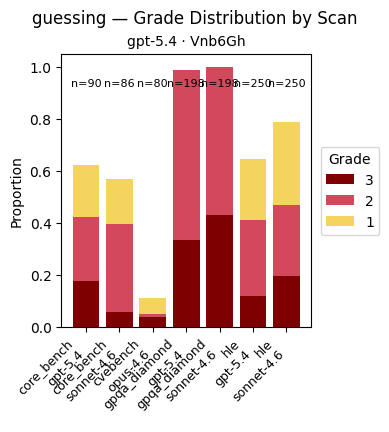

In [ ]:
display(Markdown(f"## {resolved_scanner_key} — Grade distributions"))
def _grade_distribution_data(df: pd.DataFrame, group_cols: list[str]):
    keys = (
        df.dropna(subset=["benchmark"])
        .groupby(group_cols, dropna=False)
        .size()
        .sort_index()
        .index.tolist()
    )
    keys = [k if isinstance(k, tuple) else (k,) for k in keys]

    def mask(key):
        m = pd.Series(True, index=df.index)
        for col, val in zip(group_cols, key):
            col_series = df[col]
            m &= col_series.isna() if pd.isna(val) else col_series.eq(val)
        return m

    def label(key):
        parts = []
        for col, val in zip(group_cols, key):
            parts.append(f"(no {col})" if pd.isna(val) else str(val))
        return "\n".join(parts)

    labels = [label(k) for k in keys]
    n_per = [int(df[mask(k)]["value_num"].dropna().shape[0]) for k in keys]
    grades_present = sorted(df["value_num"].dropna().astype(int).unique())
    stacks = {}
    for grade in grades_present:
        proportions = []
        for k in keys:
            sub = df[mask(k)]["value_num"].dropna()
            total = len(sub)
            proportions.append((sub.astype(int) == grade).sum() / total if total else 0)
        stacks[grade] = proportions
    return labels, n_per, grades_present, stacks


def _plot_stacked_bars(ax, labels, n_per, stacks, all_grades, title):
    x = np.arange(len(labels))
    bottom = np.zeros(len(labels))
    for grade in reversed(all_grades):
        proportions = stacks.get(grade, [0] * len(labels))
        ax.bar(x, proportions, bottom=bottom, label=str(grade),
               color=SCORE_COLORS.get(grade, "#999999"))
        bottom += np.array(proportions)
    for xi, n in zip(x, n_per):
        ax.text(xi, 0.92, f"n={n}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=10)


if scans.empty or not scan_id_order:
    print("No scans to plot.")
else:
    # Drop grade 0 from the stacked bars so each bar reads as "share at grade ≥1".
    all_grades = [g for g in sorted(scans["value_num"].dropna().astype(int).unique()) if g >= 1]
    n_runs = len(scan_id_order)
    fig, axes = plt.subplots(
        1, n_runs,
        figsize=(max(5, 5 * n_runs), 3.5),
        sharey=True,
        squeeze=False,
    )
    for ax, sid in zip(axes[0], scan_id_order):
        sub = scans[scans["scan_id"] == sid]
        labels, n_per, _grades, stacks = _grade_distribution_data(
            sub, ["benchmark", "eval_generation_model"]
        )
        _plot_stacked_bars(
            ax, labels, n_per, stacks, all_grades,
            title=scanner_label_by_scan_id.get(sid, sid),
        )
    axes[0][0].set_ylabel("Proportion")
    axes[0][-1].legend(title="Grade", loc="center left", bbox_to_anchor=(1.01, 0.5))
    fig.suptitle(f"{resolved_scanner_key} — Grade Distribution by Scan", y=.95)
    fig.tight_layout()
    save_fig(fig, "grade_distribution")
    plt.show()

### Human-labeled grades

Same stacked-bar layout, but using validation (human) grades instead of
scanner output. Validation is per-transcript, so transcripts are deduped
across scan_ids before plotting.

In [7]:
if validation is None:
    print("No validation grades — skipping human-labeled grade distribution.")
elif scans.empty:
    print("No scans loaded — skipping human-labeled grade distribution.")
else:
    human = (
        scans.drop_duplicates("transcript_id")[
            ["transcript_id", "benchmark", "eval_generation_model"]
        ]
        .merge(validation, on="transcript_id", how="inner")
        .rename(columns={"validation_grade": "value_num"})
        .dropna(subset=["value_num"])
    )
    if human.empty:
        print("No transcripts with both scan metadata and a validation grade.")
    else:
        # Drop grade 0 from the stacked bars so each bar reads as "share at grade ≥1".
        all_grades = [g for g in sorted(human["value_num"].dropna().astype(int).unique()) if g >= 1]
        labels, n_per, _grades, stacks = _grade_distribution_data(
            human, ["benchmark", "eval_generation_model"]
        )
        fig, ax = plt.subplots(figsize=(4.5,3.5))
        _plot_stacked_bars(
            ax, labels, n_per, stacks, all_grades,
            title="Human-labeled grades",
        )
        ax.set_ylabel("Proportion")
        ax.legend(title="Grade", loc="center left", bbox_to_anchor=(1.01, 0.5))
        fig.suptitle(f"{resolved_scanner_key} — Grade Distribution", y=.98)
        fig.tight_layout()
        save_fig(fig, "grade_distribution_human")
        plt.show()

No transcripts with both scan metadata and a validation grade.


One row per `(transcript_id, scan_id)` with the scanner grade pivoted into a
`scanner_grade` column, plus eval metadata and merged `validation_grade`.
Required by the confusion-matrix and focus cells below.

In [8]:
display(Markdown(f"## {resolved_scanner_key} — Comparison table"))
comparison = build_comparison_table(scans, include_scanner_source=True)
# build_comparison_table uses TRANSCRIPT_METADATA_COLUMNS (which doesn't know
# about our derived `scan_id`/`scanner_label`/`eval_generation_model`) so we
# attach those ourselves.
extra_meta = (
    scans.drop_duplicates(["transcript_id", "scanner_source"])[
        ["transcript_id", "scanner_source", "scan_id", "scanner_label",
         "scanner_model", "scan_timestamp", "eval_file",
         "eval_generation_model", "benchmark"]
    ]
)
comparison = comparison.merge(extra_meta, on=["transcript_id", "scanner_source"], how="left",
                              suffixes=("", "_meta"))
for col in ["eval_file", "benchmark"]:
    meta_col = f"{col}_meta"
    if meta_col in comparison.columns:
        comparison[col] = comparison[meta_col].fillna(comparison[col])
        comparison = comparison.drop(columns=[meta_col])

if validation is not None:
    comparison = comparison.merge(validation, on="transcript_id", how="left")
else:
    comparison["validation_grade"] = pd.NA

comparison["scanner_grade"] = pd.to_numeric(comparison.get(resolved_scanner_key), errors="coerce")
print(f"Comparison rows: {len(comparison):,}")
print(f"With scanner grade ('{resolved_scanner_key}'): {int(comparison['scanner_grade'].notna().sum()):,}")
if validation is not None:
    print(f"With validation grade: {int(comparison['validation_grade'].notna().sum()):,}")
display(comparison.head(10))

## guessing — Comparison table

KeyError: 'scanner_source'

### Per benchmark, per scan_id

Rows = scan_id, columns = benchmark. Empty cells indicate no overlap between
the scan_id and benchmark in the validation set.

In [ ]:
display(Markdown(f"## {resolved_scanner_key} — Confusion matrices vs validation"))

if validation is None:
    print("No validation grades — skipping confusion matrices vs validation.")
else:
    valid = comparison.dropna(subset=["scanner_grade", "validation_grade"]).copy()
    valid["scanner_int"] = valid["scanner_grade"].astype(int)
    valid["validation_int"] = pd.to_numeric(valid["validation_grade"], errors="coerce").astype("Int64")
    valid = valid.dropna(subset=["validation_int"]).copy()
    valid["validation_int"] = valid["validation_int"].astype(int)

    benchmarks = sorted(valid["benchmark"].dropna().unique().tolist())
    if not benchmarks or not scan_id_order:
        print("No benchmark × scan_id cells with validation overlap.")
    else:
        n_rows = len(scan_id_order)
        n_cols = len(benchmarks)
        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(3.6 * n_cols, 3.6 * n_rows),
            squeeze=False,
        )
        kappa_rows = []
        for r, sid in enumerate(scan_id_order):
            for c, bench in enumerate(benchmarks):
                ax = axes[r][c]
                cell = valid[(valid["scan_id"] == sid) & (valid["benchmark"] == bench)]
                label_left = scanner_label_by_scan_id.get(sid, sid)
                if cell.empty:
                    ax.axis("off")
                    ax.set_title(f"{label_left}\n{bench}\n(no data)", fontsize=9)
                    continue
                cm = confusion_matrix(
                    cell["validation_int"].to_numpy(),
                    cell["scanner_int"].to_numpy(),
                    GRADE_LEVELS,
                )
                kappa = quadratic_weighted_kappa(cm)
                draw_cm(
                    ax, cm,
                    xlabel="Scanner",
                    ylabel="Validation",
                    title=f"{label_left}\n{bench}\nn={int(cm.sum())}, qwκ={kappa:.3f}" if not np.isnan(kappa)
                          else f"{label_left}\n{bench}\nn={int(cm.sum())}, qwκ=—",
                )
                kappa_rows.append({
                    "scan_id": sid,
                    "scanner_label": label_left,
                    "benchmark": bench,
                    "n": int(cm.sum()),
                    "quadratic_weighted_kappa": kappa,
                })
        fig.suptitle(f"{resolved_scanner_key} — Confusion Matrices vs Validation Grade", y=1.0)
        fig.tight_layout()
        save_fig(fig, "confusion_matrices_by_benchmark")
        plt.show()

        kappa_df = pd.DataFrame(kappa_rows)
        if not kappa_df.empty:
            save_table(kappa_df, "kappa_by_benchmark")
            display_kappa = kappa_df.copy()
            display_kappa["quadratic_weighted_kappa"] = display_kappa["quadratic_weighted_kappa"].map(
                lambda v: f"{v:.3f}" if pd.notna(v) else "—"
            )
            display(display_kappa)

### Pooled confusion matrices

One 4×4 per scan_id (pooled across benchmarks) plus a final pooled-across-all
matrix. Threshold metrics use `VIOLATION_THRESHOLD`.

In [ ]:
if validation is None:
    print("No validation grades — skipping pooled confusion matrices.")
else:
    valid = comparison.dropna(subset=["scanner_grade", "validation_grade"]).copy()
    valid["scanner_int"] = valid["scanner_grade"].astype(int)
    valid["validation_int"] = pd.to_numeric(valid["validation_grade"], errors="coerce").astype("Int64")
    valid = valid.dropna(subset=["validation_int"]).copy()
    valid["validation_int"] = valid["validation_int"].astype(int)

    POOLED_THRESHOLDS = [1, 2]

    n_panels = len(scan_id_order)
    fig, axes = plt.subplots(
        1, n_panels,
        figsize=(4.0 * n_panels, 4.4),
        squeeze=False,
    )
    pooled_rows = []
    for ax, sid in zip(axes[0], scan_id_order):
        cell = valid[valid["scan_id"] == sid]
        if cell.empty:
            ax.axis("off")
            ax.set_title(f"{scanner_label_by_scan_id.get(sid, sid)}\n(no data)", fontsize=10)
            continue
        target = cell["validation_int"].to_numpy()
        pred = cell["scanner_int"].to_numpy()
        cm = confusion_matrix(target, pred, GRADE_LEVELS)
        kappa = quadratic_weighted_kappa(cm)
        kappa_str = f"{kappa:.3f}" if not np.isnan(kappa) else "—"

        per_threshold = {
            t: threshold_metrics(target, pred, threshold=t)
            for t in POOLED_THRESHOLDS
        }
        n_cell = next(iter(per_threshold.values()))["n"]

        draw_cm(
            ax, cm,
            xlabel="Scanner",
            ylabel="Validation",
            title=f"{scanner_label_by_scan_id.get(sid, sid)}\nn={n_cell}, qwκ={kappa_str}",
        )
        for t, metrics in per_threshold.items():
            pooled_rows.append({
                "scan_id": sid,
                "scanner_label": scanner_label_by_scan_id.get(sid, sid),
                "threshold": t,
                **metrics,
                "quadratic_weighted_kappa": kappa,
            })

    fig.suptitle(f"{resolved_scanner_key} — Confusion Matrices vs Validation Grade", y=1.02)
    fig.tight_layout()
    save_fig(fig, "confusion_matrices_pooled")
    plt.show()

    pooled_df = pd.DataFrame(pooled_rows)
    save_table(pooled_df, "pooled_metrics")
    display_pooled = pooled_df.copy()
    for col in ["accuracy", "sensitivity", "specificity", "precision"]:
        display_pooled[col] = display_pooled[col].map(
            lambda v: f"{v:.1%}" if pd.notna(v) else "—"
        )
    display_pooled["f1"] = display_pooled["f1"].map(
        lambda v: f"{v:.3f}" if pd.notna(v) else "—"
    )
    display_pooled["quadratic_weighted_kappa"] = display_pooled["quadratic_weighted_kappa"].map(
        lambda v: f"{v:.3f}" if pd.notna(v) else "—"
    )
    display(display_pooled)


For every pair of scan_ids that share transcripts, plot a 4×4 agreement
matrix (no validation needed) and report quadratic-weighted κ. Skipped if
fewer than two scan_ids loaded.

In [ ]:
display(Markdown(f"## {resolved_scanner_key} — Scanner-vs-scanner agreement"))
if len(scan_id_order) < 2:
    print(f"Only {len(scan_id_order)} scan_id loaded — skipping pairwise agreement.")
else:
    pair_rows = []
    pivot = (
        scans.dropna(subset=["value_num"])
        .pivot_table(
            index="transcript_id",
            columns="scan_id",
            values="value_num",
            aggfunc="first",
        )
    )
    pairs = list(itertools.combinations(scan_id_order, 2))
    n_pairs = len(pairs)
    n_cols = min(3, n_pairs)
    n_rows = (n_pairs + n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.4 * n_cols, 4.0 * n_rows),
        squeeze=False,
    )
    for idx, (sid_a, sid_b) in enumerate(pairs):
        ax = axes[idx // n_cols][idx % n_cols]
        if sid_a not in pivot.columns or sid_b not in pivot.columns:
            ax.axis("off")
            continue
        joint = pivot[[sid_a, sid_b]].dropna()
        if joint.empty:
            ax.axis("off")
            ax.set_title(f"{sid_a[:6]} vs {sid_b[:6]}\n(no overlap)", fontsize=9)
            continue
        ga = joint[sid_a].astype(int).to_numpy()
        gb = joint[sid_b].astype(int).to_numpy()
        cm = confusion_matrix(ga, gb, GRADE_LEVELS)
        kappa = quadratic_weighted_kappa(cm)
        n = int(cm.sum())
        agree = int(np.trace(cm))
        kappa_str = f"{kappa:.3f}" if not np.isnan(kappa) else "—"
        draw_cm(
            ax, cm,
            xlabel=scanner_label_by_scan_id.get(sid_b, sid_b),
            ylabel=scanner_label_by_scan_id.get(sid_a, sid_a),
            title=f"{sid_a[:6]} vs {sid_b[:6]}\nn={n}, agree={agree/n:.1%}, qwκ={kappa_str}",
        )
        pair_rows.append({
            "scan_a": sid_a,
            "scan_b": sid_b,
            "n_paired": n,
            "agree_rate": agree / n if n else float("nan"),
            "mean_abs_diff": float(np.abs(ga - gb).mean()) if n else float("nan"),
            "quadratic_weighted_kappa": kappa,
        })
    # Hide any unused axes.
    for idx in range(n_pairs, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].axis("off")
    fig.suptitle(f"{resolved_scanner_key} — Pairwise Agreement", y=.95)
    fig.tight_layout()
    save_fig(fig, "scanner_agreement")
    plt.show()

    if pair_rows:
        pair_df = pd.DataFrame(pair_rows)
        display_pair = pair_df.copy()
        display_pair["agree_rate"] = display_pair["agree_rate"].map(
            lambda v: f"{v:.1%}" if pd.notna(v) else "—"
        )
        display_pair["mean_abs_diff"] = display_pair["mean_abs_diff"].map(
            lambda v: f"{v:.2f}" if pd.notna(v) else "—"
        )
        display_pair["quadratic_weighted_kappa"] = display_pair["quadratic_weighted_kappa"].map(
            lambda v: f"{v:.3f}" if pd.notna(v) else "—"
        )
        display(display_pair)

When ≥2 scan_ids share transcripts, build composite grades across **all**
loaded scan_ids:

- `composite_floor_mean = floor(mean(grades))`
- `composite_ceil_mean = ceil(mean(grades))`
- `composite_max = max(grades)`

Then evaluate against validation. The agreement-partition table breaks
performance down by *all-positive*, *all-negative*, and *any-disagree*
buckets.

In [ ]:
display(Markdown(f"## {resolved_scanner_key} — Composite scanners"))
if len(scan_id_order) < 2:
    print(f"Only {len(scan_id_order)} scan_id loaded — skipping composite analysis.")
else:
    pivot = (
        scans.dropna(subset=["value_num"])
        .pivot_table(
            index="transcript_id",
            columns="scan_id",
            values="value_num",
            aggfunc="first",
        )
    )
    # Per-transcript composite over whichever scan_ids graded it.
    # Require ≥2 grades for a composite to be meaningful.
    grade_count = pivot.notna().sum(axis=1)
    composite = pivot[grade_count >= 2].copy()
    composite["n_scan_ids"] = grade_count[grade_count >= 2]
    composite["composite_floor_mean"] = np.floor(composite[scan_id_order].mean(axis=1, skipna=True)).astype(int)
    composite["composite_ceil_mean"] = np.ceil(composite[scan_id_order].mean(axis=1, skipna=True)).astype(int)
    composite["composite_max"] = composite[scan_id_order].max(axis=1, skipna=True).astype(int)

    print(f"Transcripts with grades from ≥2 scan_ids: {len(composite):,}")
    contributor_counts = composite["n_scan_ids"].value_counts().sort_index()
    print("Contributor-count distribution:")
    for n, count in contributor_counts.items():
        print(f"  {int(n)} scan_ids → {int(count)} transcripts")

    if validation is None:
        print("No validation grades — composite confusion matrices skipped, agreement partition only.")
        composite_eval = composite
    else:
        composite_eval = composite.merge(
            validation.set_index("transcript_id"),
            left_index=True, right_index=True, how="left",
        )

    if validation is not None:
        scored = composite_eval.dropna(subset=["validation_grade"]).copy()
        scored["validation_int"] = scored["validation_grade"].astype(int)
        composites = [
            ("floor(mean)", "composite_floor_mean"),
            ("ceil(mean)", "composite_ceil_mean"),
            ("max", "composite_max"),
        ]
        if scored.empty:
            print("No transcripts with both ≥2 scanner grades and a validation grade.")
        else:
            fig, axes = plt.subplots(1, len(composites),
                                     figsize=(4.6 * len(composites), 4.4),
                                     squeeze=False)
            metrics_rows = []
            for ax, (name, col) in zip(axes[0], composites):
                target = scored["validation_int"].to_numpy()
                pred = scored[col].astype(int).to_numpy()
                cm = confusion_matrix(target, pred, GRADE_LEVELS)
                kappa = quadratic_weighted_kappa(cm)
                metrics = threshold_metrics(target, pred, threshold=VIOLATION_THRESHOLD)
                kappa_str = f"{kappa:.3f}" if not np.isnan(kappa) else "—"
                draw_cm(
                    ax, cm,
                    xlabel="Composite",
                    ylabel="Validation",
                    title=f"composite = {name}\nn={metrics['n']}, qwκ={kappa_str}",
                )
                metrics_rows.append({"composite": name, **metrics,
                                     "quadratic_weighted_kappa": kappa})
            fig.suptitle(f"{resolved_scanner_key} — Composite vs Validation Grade (≥2 scan_ids per transcript)", y=.98)
            fig.tight_layout()
            save_fig(fig, "composite_vs_validation")
            plt.show()

            metrics_df = pd.DataFrame(metrics_rows)
            save_table(metrics_df, "composite_metrics")
            display_metrics = metrics_df.copy()
            for col in ["accuracy", "sensitivity", "specificity", "precision"]:
                display_metrics[col] = display_metrics[col].map(
                    lambda v: f"{v:.1%}" if pd.notna(v) else "—"
                )
            display_metrics["f1"] = display_metrics["f1"].map(
                lambda v: f"{v:.3f}" if pd.notna(v) else "—"
            )
            display_metrics["quadratic_weighted_kappa"] = display_metrics["quadratic_weighted_kappa"].map(
                lambda v: f"{v:.3f}" if pd.notna(v) else "—"
            )
            display(Markdown(f"### Composite metrics vs validation (threshold = {VIOLATION_THRESHOLD})"))
            display(display_metrics)

       # Agreement partition: per transcript, look only at the scan_ids that
    # actually graded it (NaN columns are ignored).
    grade_only = composite[scan_id_order]
    flags = grade_only >= VIOLATION_THRESHOLD          # NaN → False
    flags_neg = grade_only < VIOLATION_THRESHOLD       # NaN → False
    n_pos = flags.sum(axis=1)
    n_neg = flags_neg.sum(axis=1)
    n_total = composite["n_scan_ids"]

    bucket = pd.Series("any-disagree", index=composite.index)
    bucket[(n_pos == n_total) | (n_neg == n_total)] = "all-agree"
    composite["agreement_bucket"] = bucket

    composites = [
        ("floor(mean)", "composite_floor_mean"),
        ("ceil(mean)", "composite_ceil_mean"),
        ("max", "composite_max"),
    ]

    summary_rows = []
    for b, group in composite.groupby("agreement_bucket"):
        base = {"bucket": b, "n_transcripts": int(len(group))}

        if validation is None:
            summary_rows.append({**base, "composite": "—"})
            continue

        with_val = group.merge(
            validation.set_index("transcript_id"),
            left_index=True, right_index=True, how="left",
        ).dropna(subset=["validation_grade"])

        if with_val.empty:
            summary_rows.append({
                **base,
                "composite": "—",
                "n_validated": 0,
                "validation_violation_rate": float("nan"),
            })
            continue

        v_int = with_val["validation_grade"].astype(int).to_numpy()
        common = {
            **base,
            "n_validated": int(len(with_val)),
            "validation_violation_rate": float((v_int >= VIOLATION_THRESHOLD).mean()),
        }

        # In the all-agree bucket, every scanner is on the same side of the
        # threshold, so floor(mean), ceil(mean), and max produce identical
        # thresholded predictions — emit one row. For any-disagree, emit one
        # row per composite approach.
        if b == "all-agree":
            pred_int = with_val[composites[0][1]].astype(int).to_numpy()
            metrics = threshold_metrics(v_int, pred_int, threshold=VIOLATION_THRESHOLD)
            summary_rows.append({**common, "composite": "—", **metrics})
        else:
            for name, col in composites:
                pred_int = with_val[col].astype(int).to_numpy()
                metrics = threshold_metrics(v_int, pred_int, threshold=VIOLATION_THRESHOLD)
                summary_rows.append({**common, "composite": name, **metrics})

    if not summary_rows:
        print("Composite frame is empty — no agreement partition to report.")
    else:
        bucket_df = (
            pd.DataFrame(summary_rows)
            .sort_values(["bucket", "composite"])
            .reset_index(drop=True)
        )
        save_table(bucket_df, "agreement_partition")
        display_bucket = bucket_df.copy()
        if "validation_violation_rate" in display_bucket.columns:
            display_bucket["validation_violation_rate"] = display_bucket["validation_violation_rate"].map(
                lambda v: f"{v:.1%}" if pd.notna(v) else "—"
            )
        for col in ["accuracy", "sensitivity", "specificity", "precision"]:
            if col in display_bucket.columns:
                display_bucket[col] = display_bucket[col].map(
                    lambda v: f"{v:.1%}" if pd.notna(v) else "—"
                )
        if "f1" in display_bucket.columns:
            display_bucket["f1"] = display_bucket["f1"].map(
                lambda v: f"{v:.3f}" if pd.notna(v) else "—"
            )
        display(Markdown("### Performance partitioned by full agreement"))
        display(display_bucket)
